In [1]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.rainforest_connection import RainforestConnection
from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE
from src.core.models.mil_species_detector import MILSpeciesDetector
from src.core.utils.sketch import make_ax_invisible

plt.rcParams.update({
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlesize': 10, 
})

def wrap_sentence(sentence, max_length):
    words = sentence.split()
    lines = []
    current_line = ""
    for word in words:
        if len(current_line) + len(word) + (1 if current_line else 0) <= max_length:
            if current_line:
                current_line += " " 
            current_line += word
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    return "\n".join(lines)


model_path = pathlib.Path("/its/home/kag25/models/v4")
data = RainforestConnection("/its/home/kag25/data/rainforest_connection")
save_dir = pathlib.Path("/its/home/kag25/experiments/v4/species_interpolations/")
save_dir.mkdir(exist_ok=True, parents=True)

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
model_class = "vae"
vae_model_name = "jumpy-engine"
clf_model_name = "dim-oval"
vae = VAE.load_from_checkpoint(model_path / model_class / vae_model_name / "step=180000.ckpt", map_location="cuda").eval()
vae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{vae_model_name}_RFCX_frog.ckpt", map_location="cuda").eval()
vae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{vae_model_name}_run_id={clf_model_name}.parquet")
vae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Eleutherodactylus portoricensis_Forest Coqui,0.118472,0.827296,32,dim-oval,jumpy-engine,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
1,Eleutherodactylus antillensis_Red-eyed coquí,0.315153,0.990700,28,dim-oval,jumpy-engine,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
2,Eleutherodactylus brittoni_Grass coquí,0.062906,0.859486,26,dim-oval,jumpy-engine,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
3,Eleutherodactylus locustus_Locust coquí,0.262859,0.964752,28,dim-oval,jumpy-engine,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
4,Eleutherodactylus hedricki_Hedrick's coquí,0.276373,0.890589,30,dim-oval,jumpy-engine,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005


In [3]:
model_class = "sivae"
sivae_model_name = "earthy-virgo"
clf_model_name = "cautious-family"
sivae = SIVAE.load_from_checkpoint(model_path / model_class / sivae_model_name / "step=180000.ckpt", map_location="cuda").eval()
sivae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{sivae_model_name}_RFCX_frog.ckpt", map_location="cuda").eval()
sivae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{sivae_model_name}_run_id={clf_model_name}.parquet")
sivae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Leptodactylus albilabris_Caribbean White-lippe...,0.092257,0.963974,22,cautious-family,earthy-virgo,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005
1,Eleutherodactylus coqui_Common coquí,0.029379,0.528235,28,cautious-family,earthy-virgo,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005
2,Eleutherodactylus hedricki_Hedrick's coquí,0.332826,0.869487,30,cautious-family,earthy-virgo,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005
3,Eleutherodactylus wightmanae_Melodius coquí,0.150841,0.964176,37,cautious-family,earthy-virgo,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005
4,Eleutherodactylus portoricensis_Forest Coqui,0.113353,0.831565,32,cautious-family,earthy-virgo,RFCX_frog,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005


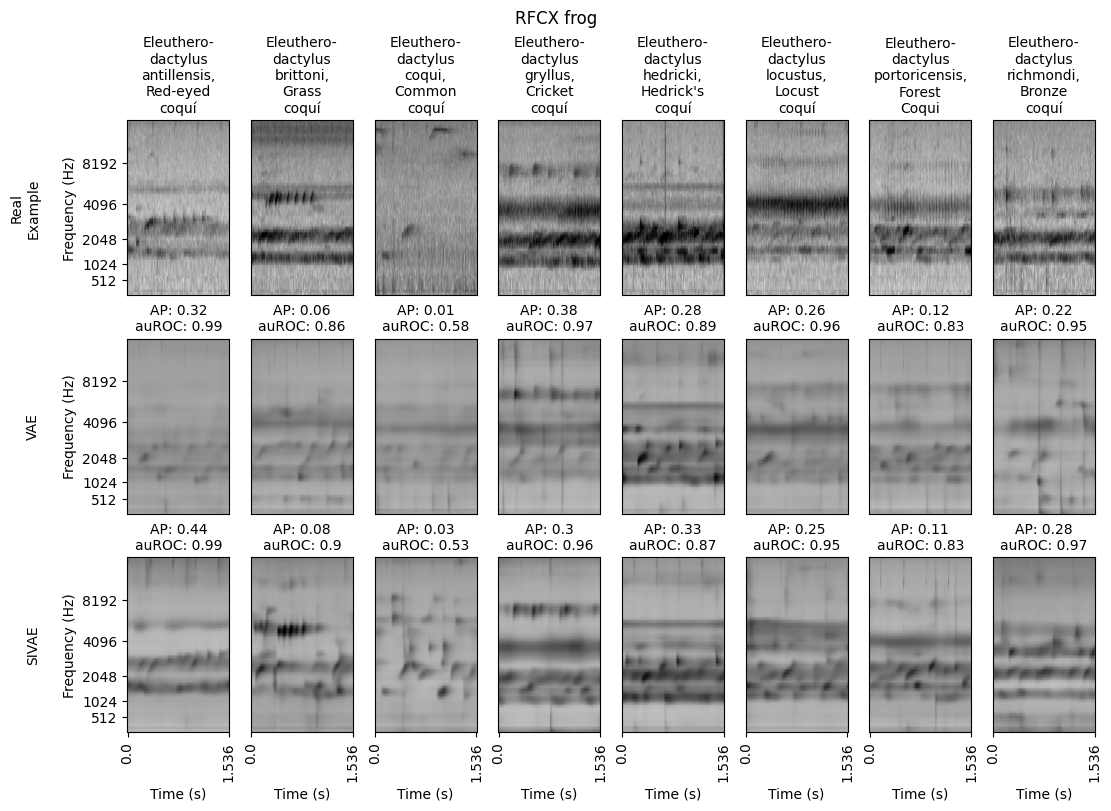

In [16]:
species_params = [ 
    {'species_name': 'Eleutherodactylus antillensis_Red-eyed coquí', 'file_name': 'train/0313e82cf.flac', 't_start_seconds': 21.472},
    {'species_name': 'Eleutherodactylus brittoni_Grass coquí', 'file_name': 'train/13c678c1d.flac', 't_start_seconds': 0.864},
    {'species_name': 'Eleutherodactylus coqui_Common coquí', 'file_name': 'train/06c44d203.flac', 't_start_seconds': 1.28},
    {'species_name': 'Eleutherodactylus gryllus_Cricket coquí', 'file_name': 'train/157a50231.flac', 't_start_seconds': 35.7867},
    {'species_name': "Eleutherodactylus hedricki_Hedrick's coquí", 'file_name': 'train/251569711.flac', 't_start_seconds': 18.2133},
    {'species_name': 'Eleutherodactylus locustus_Locust coquí', 'file_name': 'train/2bf32cf03.flac', 't_start_seconds': 21.0347},
    {'species_name': 'Eleutherodactylus portoricensis_Forest Coqui', 'file_name': 'train/068f1b8e2.flac', 't_start_seconds': 22.864},
    {'species_name': 'Eleutherodactylus richmondi_Bronze coquí', 'file_name': 'train/055088446.flac', 't_start_seconds': 58.992},
    # {'species_name': 'Eleutherodactylus unicolor_Dwarf coquí', 'file_name': 'train/10dae79ed.flac', 't_start_seconds': 30.192},
    # {'species_name': 'Eleutherodactylus wightmanae_Melodius coquí', 'file_name': 'train/0c2124550.flac', 't_start_seconds': 18.2293},
    # {'species_name': 'Leptodactylus albilabris_Caribbean White-lipped Frog', 'file_name': 'train/05b9c974c.flac', 't_start_seconds': 31.984},
]   

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(species_params) + 1,
    figsize=(11, 8),
    width_ratios=[0.01, *[0.95 / (len(species_params)) for _ in range(len(species_params))]],
    constrained_layout=True,
)
vmax, vmin = 25, -60
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

model_means = {}
for j, (model_name, vae, clf) in enumerate([(vae_model_name, vae, vae_clf), (sivae_model_name, sivae, sivae_clf)]):
    dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/RFCX_frog").setup()
    z_mean = dm.train_data.features.iloc[:, range(128)].mean()
    model_means[j] = torch.tensor(z_mean, dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0)

model_params = {
    "vae": {
        'Eleutherodactylus antillensis_Red-eyed coquí': {"delta": 25, "shift": 0.0},
        'Eleutherodactylus brittoni_Grass coquí': {"delta": 25, "shift": 0.0},
        'Eleutherodactylus coqui_Common coquí': {"delta": 25, "shift": 0.0},
        'Eleutherodactylus gryllus_Cricket coquí': {"delta": 25, "shift": 0.0},
        "Eleutherodactylus hedricki_Hedrick's coquí": {"delta": 25, "shift": 0.0},
        'Eleutherodactylus locustus_Locust coquí': {"delta": 25, "shift": 0.0},
        'Eleutherodactylus portoricensis_Forest Coqui': {"delta": 25, "shift": 0.0},
        'Eleutherodactylus richmondi_Bronze coquí': {"delta": 25, "shift": 0.0},
        # 'Eleutherodactylus unicolor_Dwarf coquí': {"delta": 15, "shift": 0.0},
        # 'Eleutherodactylus wightmanae_Melodius coquí': {"delta": 15, "shift": 0.0},
        # 'Leptodactylus albilabris_Caribbean White-lipped Frog': {"delta": 15, "shift": 0.0},
    },
    "sivae": {
        'Eleutherodactylus antillensis_Red-eyed coquí': {"delta": 15, "shift": 0.0},
        'Eleutherodactylus brittoni_Grass coquí': {"delta": 15, "shift": -0.5},
        'Eleutherodactylus coqui_Common coquí': {"delta": 15, "shift": 0.0},
        'Eleutherodactylus gryllus_Cricket coquí': {"delta": 15, "shift": 0.0},
        "Eleutherodactylus hedricki_Hedrick's coquí": {"delta": 15, "shift": 0.0},
        'Eleutherodactylus locustus_Locust coquí': {"delta": 15, "shift": 0.0},
        'Eleutherodactylus portoricensis_Forest Coqui': {"delta": 15, "shift": 0.0},
        'Eleutherodactylus richmondi_Bronze coquí': {"delta": 15, "shift": 0.0},
        # 'Eleutherodactylus unicolor_Dwarf coquí': {"delta": 15, "shift": 0.0},
        # 'Eleutherodactylus wightmanae_Melodius coquí': {"delta": 15, "shift": 0.0},
        # 'Leptodactylus albilabris_Caribbean White-lipped Frog': {"delta": 15, "shift": 0.0},
    },
}
with torch.no_grad():
    for i, params in enumerate(species_params):
        species_name, file_name, t_start_seconds = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("VAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[2, 0]
            title_ax.set_ylabel("SIVAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        ax.set_title(wrap_sentence(species_name.replace("_", ", ").replace("Eleutherodactylus", "Eleuthero-\ndactylus"), 10))
        
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        
        for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
            delta, shift = model_params[model_class][species_name].values()
            ap, auroc = scores[scores.species_name == species_name][["AP", "auROC"]].iloc[0].to_dict().values()
            z = model_means[j]
            W = clf.species_weights(species_name)
            norm = torch.linalg.norm(W)
            z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
            x_tilde_db = 20 * np.log10(x_tilde.exp())
            ax = axes[j + 1, i + 1]
            vae.front_end.plot(x_tilde_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax)
            ax.tick_params(labelbottom=False, bottom=False)
            ax.set_xlabel("")
            ax.set_title(f"AP: {np.format_float_positional(ap, precision=2)}\nauROC: {np.format_float_positional(auroc, precision=2)}")
            
for ax in axes[:, 2:].flatten():
    ax.set_ylabel("")
    ax.tick_params(labelleft=False, left=False)

for ax in axes[-1, 1:].flatten():
    ax.tick_params(labelbottom=True, bottom=True)
    ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
    ax.set_xlabel("Time (s)")

fig.suptitle("RFCX frog")
fig.savefig(save_dir / "rfcx_frog_interpolation.pdf", format="pdf")
plt.show()